In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [38]:
# nonlinear muskingum
def calculate_storage_m3(q_m3s, k, m):
    #s has units m3 
    #q has units m3/s
    #k has units m^(3(1-m)) s^m
    answer = [k * (q ** m) for q in q_m3s]
    return answer

In [54]:
# Calculate storage for a range of example flows

m=0.75 
k=2700 
div=1 
x=0

q_MLd = [1, 2, 5, 10, 20, 50, 100, 200, 
         500, 1000, 2000, 5000, 10000, 
         20000, 50000, 100000] #ML/d

q_m3s = [x / 86.4 for x in q_MLd] # m3/s
s_m3 = calculate_storage_m3(q_m3s, k, m)

In [56]:
# Read in some Source results
df_raw = pd.read_csv('muskingum_routing_m=0.75_k=2700.csv')
df = pd.DataFrame()
df["q_out_m3s"] = df_raw["Storage Routing: Default Link #115 - Storage routing: Downstream Flow (ML.day^-1)"] / 86.4
df["q_in_m3"] = df_raw["Storage Routing: Default Link #115 - Storage routing: Upstream Flow (ML.day^-1)"] / 86.4
df["s_in_m3"] = df_raw["Storage Routing: Default Link #115 - Storage routing: Storage Volume (ML)"] * 1000
print(len(df))

49854


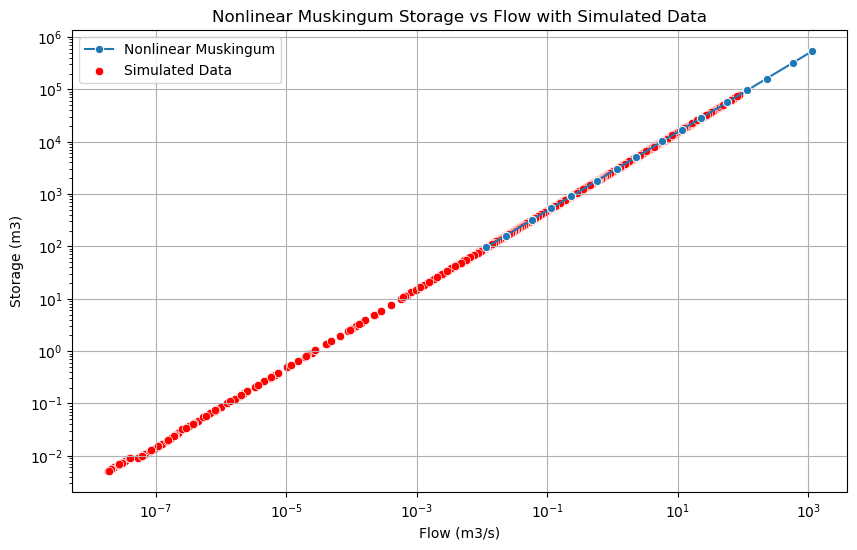

In [58]:
# Plot it all up
plt.figure(figsize=(10,6))
sns.lineplot(x=q_m3s, y=s_m3, marker='o', label='Nonlinear Muskingum')
sns.scatterplot(x=df["q_out_m3s"], y=df["s_in_m3"], color='red', label='Simulated Data')
plt.title('Nonlinear Muskingum Storage vs Flow with Simulated Data')
plt.xlabel('Flow (m3/s)')
plt.ylabel('Storage (m3)')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.legend()
plt.show()

In [81]:
def calculate_storage_m3_pwl(q_m3s, q_ref_array, lag_array):
    #s has units m3
    #q has units m3/s
    #q_ref_array has units m3/s
    #lag_array has units s

    answer = []

    # Calculate the storage for each flow in q_m3s
    for qin in q_m3s:
        # The storgae is the integral of lag(q) dq from 0 to qin, assuming that lag(q) 
        # is piecewise linear with q_ref_array and lag_array.
        # Start with storage = 0 and integrate up to qin.
        storage = 0.0
        for i in range(len(q_ref_array) - 1):
            q_ref_low = q_ref_array[i]
            q_ref_high = q_ref_array[i + 1]
            lag_low = lag_array[i]
            lag_high = lag_array[i + 1]

            if qin <= q_ref_low:
                # If the flow is less than the lowest reference flow, use the first segment
                storage += lag_low * qin
                break
            elif qin <= q_ref_high:
                # If the flow is between the current and next reference flow, integrate the current segment
                slope = (lag_high - lag_low) / (q_ref_high - q_ref_low)
                storage += lag_low * (qin - q_ref_low) + slope * (qin - q_ref_low) * (qin - q_ref_low) / 2
                break
            else:
                # If the flow is greater than the next reference flow, integrate the entire segment
                storage += lag_low * (q_ref_high - q_ref_low) + (lag_high - lag_low) * (q_ref_high - q_ref_low) / 2
        
        answer.append(storage)
    return answer

In [97]:
point_density = 20 / (np.log10(1e5) - np.log10(0.00001))
point_density

2.0

q: 1.00000e-05, lag: 3.60102e+04, storage: 3.60102e-01
q: 2.21222e-05, lag: 2.95269e+04, storage: 3.97226e-01
q: 4.89390e-05, lag: 2.42109e+04, storage: 1.11777e+00
q: 1.08264e-04, lag: 1.98520e+04, storage: 2.42477e+00
q: 2.39503e-04, lag: 1.62779e+04, storage: 4.79560e+00
q: 5.29832e-04, lag: 1.33472e+04, storage: 9.09611e+00
q: 1.17210e-03, lag: 1.09442e+04, storage: 1.68969e+01
q: 2.59294e-03, lag: 8.97381e+03, storage: 3.10471e+01
q: 5.73615e-03, lag: 7.35817e+03, storage: 5.67145e+01
q: 1.26896e-02, lag: 6.03341e+03, storage: 1.03273e+02
q: 2.80722e-02, lag: 4.94716e+03, storage: 1.87728e+02
q: 6.21017e-02, lag: 4.05648e+03, storage: 3.40923e+02
q: 1.37382e-01, lag: 3.32615e+03, storage: 6.18808e+02
q: 3.03920e-01, lag: 2.72732e+03, storage: 1.12287e+03
q: 6.72336e-01, lag: 2.23629e+03, storage: 2.03721e+03
q: 1.48735e+00, lag: 1.83367e+03, storage: 3.69575e+03
q: 3.29034e+00, lag: 1.50354e+03, storage: 6.70423e+03
q: 7.27895e+00, lag: 1.23284e+03, storage: 1.21614e+04
q: 1.61026

/var/folders/0z/t6tyxy355j56w38cvj934ygh0000gn/T/ipykernel_3808/387397041.py:25: RuntimeWarning: invalid value encountered in scalar divide
  return [num[i]/denom[i] for i in range(len(num))]
/var/folders/0z/t6tyxy355j56w38cvj934ygh0000gn/T/ipykernel_3808/387397041.py:25: RuntimeWarning: divide by zero encountered in scalar divide
  return [num[i]/denom[i] for i in range(len(num))]


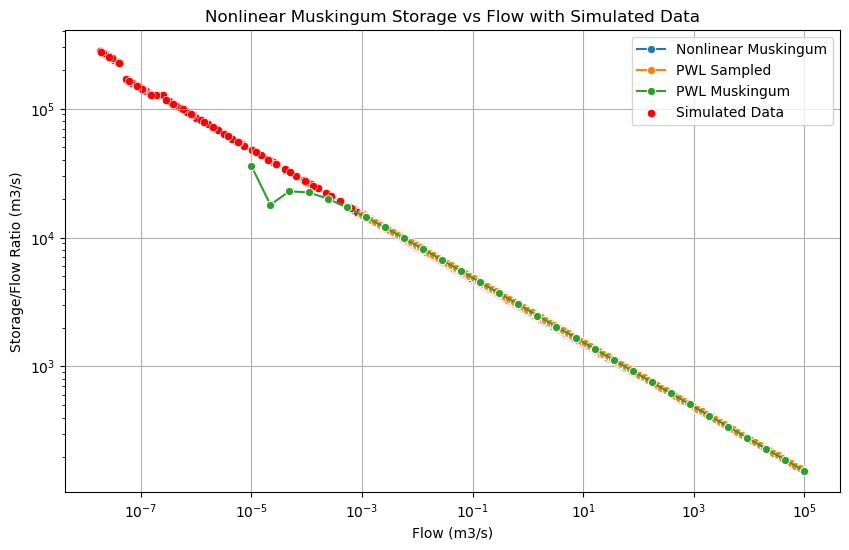

In [98]:
# If we were to construct a piecewise linear lag function to match the nonlinear 
# muskingum, how would we do that?

# Lag is the derivative of storage with respect to flow, so we can calculate it as 
# the slope of the storage curve at the reference flows.
# s = k * q^m
# lag = ds/dq = k * m * q^(m-1)

# Create PWL to match the nonlinear muskingum

n_pwl = 30
q_pwl_muskingum = np.logspace(np.log10(0.00001), np.log10(1e5), n_pwl)
l_pwl_muskingum = [k * m * (q ** (m - 1)) for q in q_pwl_muskingum]
s_pwl_muskingum = calculate_storage_m3_pwl(q_pwl_muskingum, q_pwl_muskingum, l_pwl_muskingum)
for i in range(len(q_pwl_muskingum)):
    print(f"q: {q_pwl_muskingum[i]:.5e}, lag: {l_pwl_muskingum[i]:.5e}, storage: {s_pwl_muskingum[i]:.5e}")

# Now how well does it work between the reference flows?
n_sample = 100
q_sample = np.logspace(np.log10(0.001), np.log10(1e5), n_sample)
s_sample = calculate_storage_m3_pwl(q_sample, q_pwl_muskingum, l_pwl_muskingum)

# Storage ratio
def ratio(num, denom):
    return [num[i]/denom[i] for i in range(len(num))]        

# Add these to the plot
plt.figure(figsize=(10,6))
sns.lineplot(x=q_m3s, y=ratio(s_m3, q_m3s), marker='o', label='Nonlinear Muskingum')
sns.lineplot(x=q_sample, y=ratio(s_sample, q_sample), marker='o', label='PWL Sampled')
sns.lineplot(x=q_pwl_muskingum, y=ratio(s_pwl_muskingum, q_pwl_muskingum), marker='o', label='PWL Muskingum')
sns.scatterplot(x=df["q_out_m3s"], y=ratio(df["s_in_m3"], df["q_out_m3s"]), color='red', label='Simulated Data')
plt.title('Nonlinear Muskingum Storage vs Flow with Simulated Data')
plt.xlabel('Flow (m3/s)')
plt.ylabel('Storage/Flow Ratio (m3/s)')
plt.yscale('log')
plt.xscale('log')
plt.grid()
plt.legend()
plt.show()


In [120]:
def make_pwl_table(node_name, m, k, n_per_decade, q_MLd_min, q_MLd_max):
    n_per_decade = 2
    q_MLd_min = 0.001
    q_MLd_max = 1e9

    n = int(n_per_decade * (np.log10(q_MLd_max) - np.log10(q_MLd_min))) + 1
    q_pwl = np.logspace(np.log10(q_MLd_min), np.log10(q_MLd_max), n)
    l_pwl = [(k * m * ((q / 86.4) ** (m - 1)))/ 86400 for q in q_pwl]
    
    print(f"# {node_name}")
    ans = ""
    for i in range(len(q_pwl)):
        ans += f"{q_pwl[i]:.2e}, {l_pwl[i]:.2e}, "
    print(f"pwl = {ans}\n")

In [121]:
make_pwl_table("Node 0011", m=0.75, k=2700, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0011
pwl = 1.00e-03, 4.02e-01, 3.16e-03, 3.01e-01, 1.00e-02, 2.26e-01, 3.16e-02, 1.69e-01, 1.00e-01, 1.27e-01, 3.16e-01, 9.53e-02, 1.00e+00, 7.15e-02, 3.16e+00, 5.36e-02, 1.00e+01, 4.02e-02, 3.16e+01, 3.01e-02, 1.00e+02, 2.26e-02, 3.16e+02, 1.69e-02, 1.00e+03, 1.27e-02, 3.16e+03, 9.53e-03, 1.00e+04, 7.15e-03, 3.16e+04, 5.36e-03, 1.00e+05, 4.02e-03, 3.16e+05, 3.01e-03, 1.00e+06, 2.26e-03, 3.16e+06, 1.69e-03, 1.00e+07, 1.27e-03, 3.16e+07, 9.53e-04, 1.00e+08, 7.15e-04, 3.16e+08, 5.36e-04, 1.00e+09, 4.02e-04, 



In [123]:
make_pwl_table("Node 0036", m=0.75, k=7500, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0036
pwl = 1.00e-03, 1.12e+00, 3.16e-03, 8.37e-01, 1.00e-02, 6.28e-01, 3.16e-02, 4.71e-01, 1.00e-01, 3.53e-01, 3.16e-01, 2.65e-01, 1.00e+00, 1.98e-01, 3.16e+00, 1.49e-01, 1.00e+01, 1.12e-01, 3.16e+01, 8.37e-02, 1.00e+02, 6.28e-02, 3.16e+02, 4.71e-02, 1.00e+03, 3.53e-02, 3.16e+03, 2.65e-02, 1.00e+04, 1.98e-02, 3.16e+04, 1.49e-02, 1.00e+05, 1.12e-02, 3.16e+05, 8.37e-03, 1.00e+06, 6.28e-03, 3.16e+06, 4.71e-03, 1.00e+07, 3.53e-03, 3.16e+07, 2.65e-03, 1.00e+08, 1.98e-03, 3.16e+08, 1.49e-03, 1.00e+09, 1.12e-03, 



In [125]:
make_pwl_table("Node 0051", m=0.75, k=51660, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0051
pwl = 1.00e-03, 7.69e+00, 3.16e-03, 5.77e+00, 1.00e-02, 4.32e+00, 3.16e-02, 3.24e+00, 1.00e-01, 2.43e+00, 3.16e-01, 1.82e+00, 1.00e+00, 1.37e+00, 3.16e+00, 1.03e+00, 1.00e+01, 7.69e-01, 3.16e+01, 5.77e-01, 1.00e+02, 4.32e-01, 3.16e+02, 3.24e-01, 1.00e+03, 2.43e-01, 3.16e+03, 1.82e-01, 1.00e+04, 1.37e-01, 3.16e+04, 1.03e-01, 1.00e+05, 7.69e-02, 3.16e+05, 5.77e-02, 1.00e+06, 4.32e-02, 3.16e+06, 3.24e-02, 1.00e+07, 2.43e-02, 3.16e+07, 1.82e-02, 1.00e+08, 1.37e-02, 3.16e+08, 1.03e-02, 1.00e+09, 7.69e-03, 



In [127]:
make_pwl_table("Node 0092", m=0.75, k=64260, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0092
pwl = 1.00e-03, 9.56e+00, 3.16e-03, 7.17e+00, 1.00e-02, 5.38e+00, 3.16e-02, 4.03e+00, 1.00e-01, 3.02e+00, 3.16e-01, 2.27e+00, 1.00e+00, 1.70e+00, 3.16e+00, 1.28e+00, 1.00e+01, 9.56e-01, 3.16e+01, 7.17e-01, 1.00e+02, 5.38e-01, 3.16e+02, 4.03e-01, 1.00e+03, 3.02e-01, 3.16e+03, 2.27e-01, 1.00e+04, 1.70e-01, 3.16e+04, 1.28e-01, 1.00e+05, 9.56e-02, 3.16e+05, 7.17e-02, 1.00e+06, 5.38e-02, 3.16e+06, 4.03e-02, 1.00e+07, 3.02e-02, 3.16e+07, 2.27e-02, 1.00e+08, 1.70e-02, 3.16e+08, 1.28e-02, 1.00e+09, 9.56e-03, 



In [130]:
make_pwl_table("Node 0101", m=0.75, k=82440, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0101
pwl = 1.00e-03, 1.23e+01, 3.16e-03, 9.20e+00, 1.00e-02, 6.90e+00, 3.16e-02, 5.17e+00, 1.00e-01, 3.88e+00, 3.16e-01, 2.91e+00, 1.00e+00, 2.18e+00, 3.16e+00, 1.64e+00, 1.00e+01, 1.23e+00, 3.16e+01, 9.20e-01, 1.00e+02, 6.90e-01, 3.16e+02, 5.17e-01, 1.00e+03, 3.88e-01, 3.16e+03, 2.91e-01, 1.00e+04, 2.18e-01, 3.16e+04, 1.64e-01, 1.00e+05, 1.23e-01, 3.16e+05, 9.20e-02, 1.00e+06, 6.90e-02, 3.16e+06, 5.17e-02, 1.00e+07, 3.88e-02, 3.16e+07, 2.91e-02, 1.00e+08, 2.18e-02, 3.16e+08, 1.64e-02, 1.00e+09, 1.23e-02, 



In [129]:
make_pwl_table("Node 0150", m=0.75, k=77760, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0150
pwl = 1.00e-03, 1.16e+01, 3.16e-03, 8.68e+00, 1.00e-02, 6.51e+00, 3.16e-02, 4.88e+00, 1.00e-01, 3.66e+00, 3.16e-01, 2.74e+00, 1.00e+00, 2.06e+00, 3.16e+00, 1.54e+00, 1.00e+01, 1.16e+00, 3.16e+01, 8.68e-01, 1.00e+02, 6.51e-01, 3.16e+02, 4.88e-01, 1.00e+03, 3.66e-01, 3.16e+03, 2.74e-01, 1.00e+04, 2.06e-01, 3.16e+04, 1.54e-01, 1.00e+05, 1.16e-01, 3.16e+05, 8.68e-02, 1.00e+06, 6.51e-02, 3.16e+06, 4.88e-02, 1.00e+07, 3.66e-02, 3.16e+07, 2.74e-02, 1.00e+08, 2.06e-02, 3.16e+08, 1.54e-02, 1.00e+09, 1.16e-02, 



In [131]:
make_pwl_table("Node 0199", m=0.75, k=49680, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0199
pwl = 1.00e-03, 7.39e+00, 3.16e-03, 5.54e+00, 1.00e-02, 4.16e+00, 3.16e-02, 3.12e+00, 1.00e-01, 2.34e+00, 3.16e-01, 1.75e+00, 1.00e+00, 1.31e+00, 3.16e+00, 9.86e-01, 1.00e+01, 7.39e-01, 3.16e+01, 5.54e-01, 1.00e+02, 4.16e-01, 3.16e+02, 3.12e-01, 1.00e+03, 2.34e-01, 3.16e+03, 1.75e-01, 1.00e+04, 1.31e-01, 3.16e+04, 9.86e-02, 1.00e+05, 7.39e-02, 3.16e+05, 5.54e-02, 1.00e+06, 4.16e-02, 3.16e+06, 3.12e-02, 1.00e+07, 2.34e-02, 3.16e+07, 1.75e-02, 1.00e+08, 1.31e-02, 3.16e+08, 9.86e-03, 1.00e+09, 7.39e-03, 



In [132]:
make_pwl_table("Node 0218", m=0.75, k=15120, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0218
pwl = 1.00e-03, 2.25e+00, 3.16e-03, 1.69e+00, 1.00e-02, 1.27e+00, 3.16e-02, 9.49e-01, 1.00e-01, 7.12e-01, 3.16e-01, 5.34e-01, 1.00e+00, 4.00e-01, 3.16e+00, 3.00e-01, 1.00e+01, 2.25e-01, 3.16e+01, 1.69e-01, 1.00e+02, 1.27e-01, 3.16e+02, 9.49e-02, 1.00e+03, 7.12e-02, 3.16e+03, 5.34e-02, 1.00e+04, 4.00e-02, 3.16e+04, 3.00e-02, 1.00e+05, 2.25e-02, 3.16e+05, 1.69e-02, 1.00e+06, 1.27e-02, 3.16e+06, 9.49e-03, 1.00e+07, 7.12e-03, 3.16e+07, 5.34e-03, 1.00e+08, 4.00e-03, 3.16e+08, 3.00e-03, 1.00e+09, 2.25e-03, 



In [133]:
make_pwl_table("Node 0228", m=0.75, k=10800, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0228
pwl = 1.00e-03, 1.61e+00, 3.16e-03, 1.21e+00, 1.00e-02, 9.04e-01, 3.16e-02, 6.78e-01, 1.00e-01, 5.08e-01, 3.16e-01, 3.81e-01, 1.00e+00, 2.86e-01, 3.16e+00, 2.14e-01, 1.00e+01, 1.61e-01, 3.16e+01, 1.21e-01, 1.00e+02, 9.04e-02, 3.16e+02, 6.78e-02, 1.00e+03, 5.08e-02, 3.16e+03, 3.81e-02, 1.00e+04, 2.86e-02, 3.16e+04, 2.14e-02, 1.00e+05, 1.61e-02, 3.16e+05, 1.21e-02, 1.00e+06, 9.04e-03, 3.16e+06, 6.78e-03, 1.00e+07, 5.08e-03, 3.16e+07, 3.81e-03, 1.00e+08, 2.86e-03, 3.16e+08, 2.14e-03, 1.00e+09, 1.61e-03, 



In [134]:
make_pwl_table("Node 0231", m=0.75, k=17280, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0231
pwl = 1.00e-03, 2.57e+00, 3.16e-03, 1.93e+00, 1.00e-02, 1.45e+00, 3.16e-02, 1.08e+00, 1.00e-01, 8.13e-01, 3.16e-01, 6.10e-01, 1.00e+00, 4.57e-01, 3.16e+00, 3.43e-01, 1.00e+01, 2.57e-01, 3.16e+01, 1.93e-01, 1.00e+02, 1.45e-01, 3.16e+02, 1.08e-01, 1.00e+03, 8.13e-02, 3.16e+03, 6.10e-02, 1.00e+04, 4.57e-02, 3.16e+04, 3.43e-02, 1.00e+05, 2.57e-02, 3.16e+05, 1.93e-02, 1.00e+06, 1.45e-02, 3.16e+06, 1.08e-02, 1.00e+07, 8.13e-03, 3.16e+07, 6.10e-03, 1.00e+08, 4.57e-03, 3.16e+08, 3.43e-03, 1.00e+09, 2.57e-03, 



In [135]:
make_pwl_table("Node 0251", m=0.75, k=77040, n_per_decade=2, q_MLd_min=0.001, q_MLd_max=100000)

# Node 0251
pwl = 1.00e-03, 1.15e+01, 3.16e-03, 8.60e+00, 1.00e-02, 6.45e+00, 3.16e-02, 4.83e+00, 1.00e-01, 3.63e+00, 3.16e-01, 2.72e+00, 1.00e+00, 2.04e+00, 3.16e+00, 1.53e+00, 1.00e+01, 1.15e+00, 3.16e+01, 8.60e-01, 1.00e+02, 6.45e-01, 3.16e+02, 4.83e-01, 1.00e+03, 3.63e-01, 3.16e+03, 2.72e-01, 1.00e+04, 2.04e-01, 3.16e+04, 1.53e-01, 1.00e+05, 1.15e-01, 3.16e+05, 8.60e-02, 1.00e+06, 6.45e-02, 3.16e+06, 4.83e-02, 1.00e+07, 3.63e-02, 3.16e+07, 2.72e-02, 1.00e+08, 2.04e-02, 3.16e+08, 1.53e-02, 1.00e+09, 1.15e-02, 

